In [49]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd


In [18]:
# ------------------------------------------------------------
# STEP 1: Load all carline CSV files from the Data folder
# ------------------------------------------------------------

import os
import pandas as pd

# Folder containing your cleaned CSV datasets
data_folder = "../Data/01_clean"  # adjust if needed

# Get list of all CSV files in folder
csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]

# Dictionary: {carline_key: dataframe}
stiffnessMatrices = {}

for file in csv_files:
    # Extract characters 4 to 7 (Python slicing 3:7)
    key = file[3:7].lower()      # lowercase for consistency (c174, w214, ...)
    
    # Load file into DataFrame
    df = pd.read_csv(os.path.join(data_folder, file))
    
    # Store in dictionary
    stiffnessMatrices[key] = df

print(f"Loaded {len(stiffnessMatrices)} CSV files.\n")

# Print the keys to confirm
print("Carline datasets loaded:")
for name in stiffnessMatrices.keys():
    print(f" - {name}")

Loaded 5 CSV files.

Carline datasets loaded:
 - c174
 - w214
 - w520
 - x296
 - x540


In [19]:
# lets print head of each
for name in stiffnessMatrices.keys():
    print(f"Head of {name}:")
    print(stiffnessMatrices[name].head())
    print("\n")

Head of c174:
        x      y       z  Thickness_r1_1  r1P2_1  r1P3_1  Distance_r1_1  \
0  855.23 -76.90  523.30            0.66    71.7    0.21           8.76   
1  855.38 -58.73  524.91            0.66    71.7    0.21           8.33   
2  855.65 -36.02  526.05            0.66    71.7    0.21           7.85   
3  855.91 -14.44  527.18            0.66    71.7    0.21           7.36   
4  856.45   9.41  526.05            0.66    71.7    0.21           7.85   

   Thickness_r1_2  r1P2_2  r1P3_2  ...  Distance_r2_8  Thickness_r2_9  r2P2_9  \
0            1.84    71.7    0.21  ...           0.00            2.26    2.40   
1            1.86    71.7    0.21  ...           0.00            2.26    2.40   
2            1.86    71.7    0.21  ...           4.18            2.24    2.95   
3            1.86    71.7    0.21  ...          11.61            3.40  210.00   
4            1.86    71.7    0.21  ...           4.36            2.24    2.95   

   r2P3_9  Distance_r2_9  Thickness_r2_10  r2P2_

In [20]:
stiffnessMatrices['c174'].head()

,x,y,z,Thickness_r1_1,r1P2_1,r1P3_1,Distance_r1_1,Thickness_r1_2,r1P2_2,r1P3_2,...,Distance_r2_8,Thickness_r2_9,r2P2_9,r2P3_9,Distance_r2_9,Thickness_r2_10,r2P2_10,r2P3_10,Distance_r2_10,A3MS
0,855.23,-76.90,523.30,0.66,71.7,0.21,8.76,1.84,71.7,0.21,...,0.00,2.26,2.40,0.40,4.63,2.24,2.95,0.35,19.98,40.92
1,855.38,-58.73,524.91,0.66,71.7,0.21,8.33,1.86,71.7,0.21,...,0.00,2.26,2.40,0.40,4.35,2.24,2.95,0.35,17.96,44.93
2,855.65,-36.02,526.05,0.66,71.7,0.21,7.85,1.86,71.7,0.21,...,4.18,2.24,2.95,0.35,16.95,3.25,210.00,0.30,3.95,49.97
3,855.91,-14.44,527.18,0.66,71.7,0.21,7.36,1.86,71.7,0.21,...,11.61,3.40,210.00,0.30,0.00,0.00,0.00,0.00,0.00,48.94
4,856.45,9.41,526.05,0.66,71.7,0.21,7.85,1.86,71.7,0.21,...,4.36,2.24,2.95,0.35,18.79,3.83,210.00,0.30,0.00,43.04


In [23]:
# Rename patterned columns:
# Thickness_r1_x  -> r1_thk_x
# Distance_r1_x   -> r1_dist_x
# r1P2_x          -> r1_E_x
# r1P3_x          -> r1_PR_x
# (same for r2)

def rename_columns(df):
    renamed = []
    for c in df.columns:
        nc = c
        
        # Thickness_r1_5 → r1_thk_5
        nc = re.sub(r'^Thickness_r([12])_(\d+)$', r'r\1_thk_\2', nc, flags=re.IGNORECASE)
        
        # Distance_r1_5 → r1_dist_5
        nc = re.sub(r'^Distance_r([12])_(\d+)$', r'r\1_dist_\2', nc, flags=re.IGNORECASE)

        # r1P2_5 → r1_E_5
        nc = re.sub(r'^r([12])P2_(\d+)$', r'r\1_E_\2', nc, flags=re.IGNORECASE)

        # r1P3_5 → r1_PR_5
        nc = re.sub(r'^r([12])P3_(\d+)$', r'r\1_PR_\2', nc, flags=re.IGNORECASE)

        # enforce lowercase for uniformity
        renamed.append(nc.lower())

    df.columns = renamed
    return df

# Apply renaming to all datasets
for k in stiffnessMatrices:
    stiffnessMatrices[k] = rename_columns(stiffnessMatrices[k])

# Check that renaming worked
sample_key = next(iter(stiffnessMatrices))
print(f"Sample columns for: {sample_key}")

filtered_cols = [
    col for col in stiffnessMatrices[sample_key].columns
    if col.startswith('r1_') or col.startswith('r2_')
]

print(filtered_cols[:30])

Sample columns for: c174
['r1_thk_1', 'r1_e_1', 'r1_pr_1', 'r1_dist_1', 'r1_thk_2', 'r1_e_2', 'r1_pr_2', 'r1_dist_2', 'r1_thk_3', 'r1_e_3', 'r1_pr_3', 'r1_dist_3', 'r1_thk_4', 'r1_e_4', 'r1_pr_4', 'r1_dist_4', 'r1_thk_5', 'r1_e_5', 'r1_pr_5', 'r1_dist_5', 'r1_thk_6', 'r1_e_6', 'r1_pr_6', 'r1_dist_6', 'r1_thk_7', 'r1_e_7', 'r1_pr_7', 'r1_dist_7', 'r1_thk_8', 'r1_e_8']


In [24]:
stiffnessMatrices['w214'].head()

,x,y,z,r1_thk_1,r1_e_1,r1_pr_1,r1_dist_1,r1_thk_2,r1_e_2,r1_pr_2,...,r2_dist_8,r2_thk_9,r2_e_9,r2_pr_9,r2_dist_9,r2_thk_10,r2_e_10,r2_pr_10,r2_dist_10,a3ms
0,976.70,-83.65,610.27,0.810688,0.4,0.4,1.616276e+00,11.856584,70.0,0.30,...,0.000000,10.752756,44.80,0.35,0.592384,9.338242,44.8,0.35,10.209091,77.1882
1,992.44,-87.38,591.95,0.654165,0.4,0.4,1.890000e-12,0.882384,44.8,0.35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.3488
2,1007.95,-93.41,572.35,0.671832,0.4,0.4,1.840000e-12,0.908588,44.8,0.35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.6234
3,1019.24,-92.78,558.19,0.700179,0.4,0.4,1.910000e-12,0.944612,44.8,0.35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.7177
4,1028.79,-94.53,546.15,0.720871,0.4,0.4,1.870000e-12,0.985209,44.8,0.35,...,8.867856,6.559560,1.15,0.43,NaN,NaN,NaN,NaN,NaN,90.1984


In [25]:
output_folder = "../Data/02_clm_renamed"
os.makedirs(output_folder, exist_ok=True)

for name, df in stiffnessMatrices.items():
    output_path = os.path.join(output_folder, f"{name}_clm_renamed.csv")
    df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

Saved: ../Data/02_clm_renamed\c174_clm_renamed.csv
Saved: ../Data/02_clm_renamed\w214_clm_renamed.csv
Saved: ../Data/02_clm_renamed\w520_clm_renamed.csv
Saved: ../Data/02_clm_renamed\x296_clm_renamed.csv
Saved: ../Data/02_clm_renamed\x540_clm_renamed.csv


In [ ]:
# Step: Split (bifurcate) each carline dataframe into R1 and R2 direction subsets

import pandas as pd

r1_df_dict = {}
r2_df_dict = {}

for key, df in stiffnessMatrices.items():
    target_col = df.columns[-1]  # assuming last column is the target (y)
    r1_cols = [c for c in df.columns if c.startswith("r1_")]
    r2_cols = [c for c in df.columns if c.startswith("r2_")]

    # Ensure target column included (if not already in the directional columns)
    if target_col not in r1_cols:
        r1_subset = df[r1_cols + ([target_col] if target_col not in r1_cols else [])].copy()
    else:
        r1_subset = df[r1_cols].copy()

    if target_col not in r2_cols:
        r2_subset = df[r2_cols + ([target_col] if target_col not in r2_cols else [])].copy()
    else:
        r2_subset = df[r2_cols].copy()

    r1_df_dict[key] = r1_subset
    r2_df_dict[key] = r2_subset

print(f"Created {len(r1_df_dict)} R1 direction dataframes and {len(r2_df_dict)} R2 direction dataframes.")

# Optional: Combine all carlines per direction (outer concat to align columns)
r1_all = pd.concat(r1_df_dict.values(), axis=0, ignore_index=True, sort=False)
r2_all = pd.concat(r2_df_dict.values(), axis=0, ignore_index=True, sort=False)

print("R1 combined shape:", r1_all.shape)
print("R2 combined shape:", r2_all.shape)

# Quick column check (first 20)
print("Sample R1 columns:", list(r1_all.columns)[:20])
print("Sample R2 columns:", list(r2_all.columns)[:20])

# r1_all.head()
# r2_all.head() are created and ready for next steps (EDA, feature engineering, modeling)

Created 5 R1 direction dataframes and 5 R2 direction dataframes.
R1 combined shape: (1590, 41)
R2 combined shape: (1590, 41)
Sample R1 columns: ['r1_thk_1', 'r1_e_1', 'r1_pr_1', 'r1_dist_1', 'r1_thk_2', 'r1_e_2', 'r1_pr_2', 'r1_dist_2', 'r1_thk_3', 'r1_e_3', 'r1_pr_3', 'r1_dist_3', 'r1_thk_4', 'r1_e_4', 'r1_pr_4', 'r1_dist_4', 'r1_thk_5', 'r1_e_5', 'r1_pr_5', 'r1_dist_5']
Sample R2 columns: ['r2_thk_1', 'r2_e_1', 'r2_pr_1', 'r2_dist_1', 'r2_thk_2', 'r2_e_2', 'r2_pr_2', 'r2_dist_2', 'r2_thk_3', 'r2_e_3', 'r2_pr_3', 'r2_dist_3', 'r2_thk_4', 'r2_e_4', 'r2_pr_4', 'r2_dist_4', 'r2_thk_5', 'r2_e_5', 'r2_pr_5', 'r2_dist_5']


   STEP 4 — Cleaning R1 dataset

===== R1 THK — STATS =====
            count      mean        std       min       25%       50%  \
r1_thk_1   1590.0  1.361574   5.337543  0.007799  0.688236  1.069507   
r1_thk_2   1590.0  1.447373   2.936914  0.000000  0.831708  0.952277   
r1_thk_3   1590.0  2.683300   2.451582  0.000000  1.800743  2.120403   
r1_thk_4   1590.0  2.985878   2.922570  0.000000  1.662549  2.511609   
r1_thk_5   1590.0  2.721345   3.610667  0.000000  0.591950  2.494377   
r1_thk_6   1583.0  3.142365   4.280825  0.000000  0.000000  2.556981   
r1_thk_7   1560.0  4.156319   9.965809  0.000000  0.000000  1.533982   
r1_thk_8   1514.0  1.914488   5.001839  0.000000  0.000000  0.000000   
r1_thk_9   1486.0  4.297001  12.270267  0.000000  0.000000  0.000000   
r1_thk_10  1440.0  2.559107   9.957500  0.000000  0.000000  0.000000   

                75%         max  
r1_thk_1   1.212723  208.808517  
r1_thk_2   2.013260   72.397740  
r1_thk_3   2.889392   18.483768  
r1_thk_4   

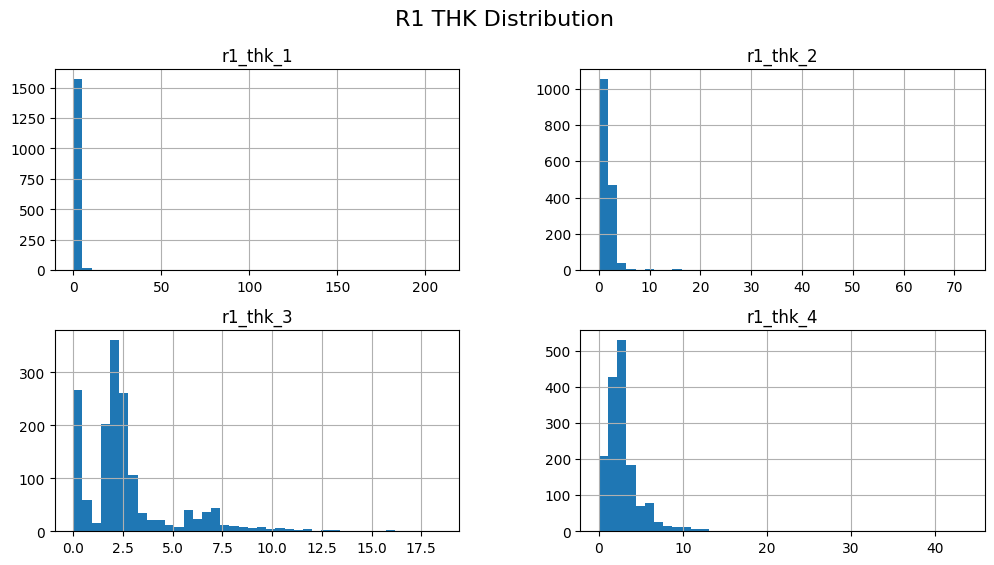


===== R1 DIST — STATS =====
             count       mean        std  min           25%       50%  \
r1_dist_1   1590.0   1.564143   5.093831  0.0  2.572500e-12  0.301625   
r1_dist_2   1589.0   7.049907   8.686454  0.0  1.108065e+00  5.784732   
r1_dist_3   1590.0  11.660305  14.853903  0.0  9.747373e-01  7.559335   
r1_dist_4   1590.0  15.230384  22.201933  0.0  1.112012e+00  8.012500   
r1_dist_5   1583.0  18.419538  29.387548  0.0  0.000000e+00  3.955866   
r1_dist_6   1560.0  17.763301  29.112102  0.0  0.000000e+00  2.512621   
r1_dist_7   1514.0  10.368758  25.471030  0.0  0.000000e+00  0.000000   
r1_dist_8   1486.0   7.954116  23.760213  0.0  0.000000e+00  0.000000   
r1_dist_9   1440.0   3.156263  12.842503  0.0  0.000000e+00  0.000000   
r1_dist_10  1414.0   3.486972  12.625240  0.0  0.000000e+00  0.000000   

                  75%         max  
r1_dist_1    0.366212  105.833949  
r1_dist_2    8.198187  150.730000  
r1_dist_3   18.750083  155.040000  
r1_dist_4   19.597442  

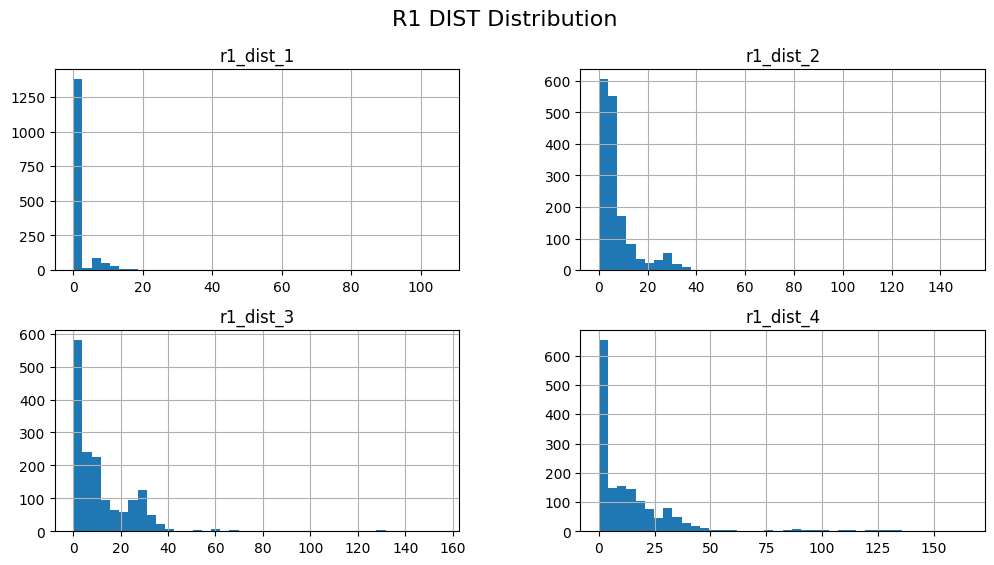


===== R1 E — STATS =====
          count        mean          std  min        25%    50%    75%  \
r1_e_1   1589.0   61.695514    21.781457  0.1  69.000000  69.00  71.70   
r1_e_2   1584.0   62.218946    19.452301  0.1  69.000000  69.00  71.70   
r1_e_3   1405.0   61.285139    20.117788  0.1  69.000000  69.00  69.00   
r1_e_4   1477.0   51.509212    31.863605  0.0  22.540000  69.00  69.00   
r1_e_5   1527.0  305.431747  3521.338931  0.0   2.350000  24.00  69.00   
r1_e_6   1562.0  291.878649  3482.562307  0.0   1.150000   2.95  69.00   
r1_e_7   1468.0  930.919085  6403.210845  0.0   0.100000   2.95  44.80   
r1_e_8   1441.0  500.724459  4670.411323  0.0   0.006304   2.35   2.95   
r1_e_9   1451.0  265.870708  3408.078279  0.0   0.000000   0.10   2.95   
r1_e_10  1400.0  256.184196  3871.662464  0.0   0.000000   0.10   2.35   

             max  
r1_e_1      71.7  
r1_e_2      71.7  
r1_e_3     210.0  
r1_e_4     210.0  
r1_e_5   46020.0  
r1_e_6   46020.0  
r1_e_7   46020.0  
r1_e_8 

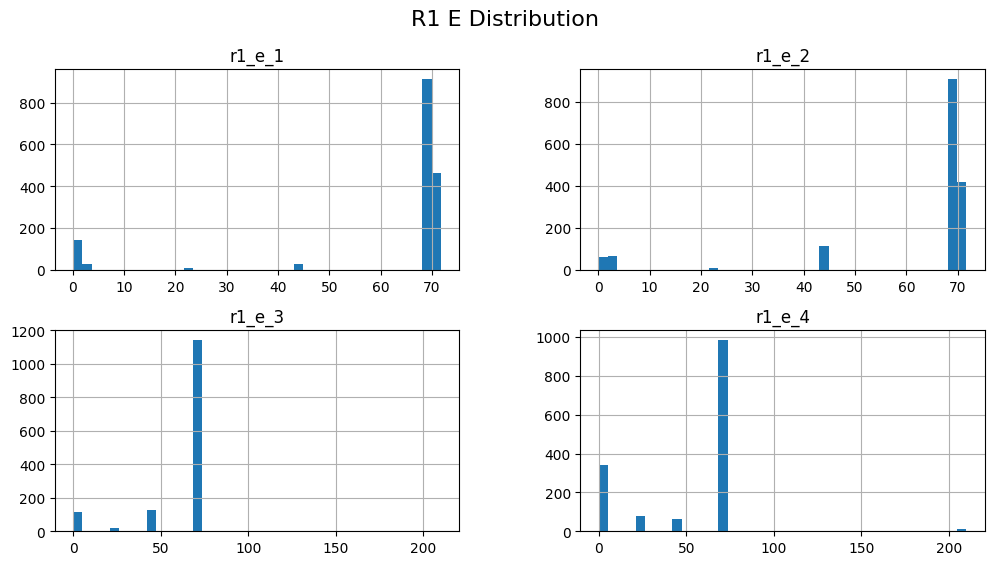


===== R1 PR — STATS =====
           count      mean       std    min   25%   50%   75%   max
r1_pr_1   1589.0  0.241040  0.062232  0.210  0.21  0.22  0.22  0.45
r1_pr_2   1584.0  0.240972  0.057548  0.210  0.21  0.22  0.22  0.45
r1_pr_3   1405.0  0.245245  0.063192  0.001  0.22  0.22  0.22  0.45
r1_pr_4   1477.0  0.261519  0.072029  0.000  0.22  0.22  0.34  0.45
r1_pr_5   1527.0  0.286743  0.098315  0.000  0.22  0.34  0.35  0.45
r1_pr_6   1562.0  0.294147  0.115127  0.000  0.22  0.34  0.35  0.49
r1_pr_7   1468.0  0.281344  0.141282  0.000  0.22  0.34  0.35  0.49
r1_pr_8   1441.0  0.247387  0.160839  0.000  0.07  0.32  0.35  0.45
r1_pr_9   1451.0  0.191129  0.170923  0.000  0.00  0.30  0.35  0.45
r1_pr_10  1400.0  0.148971  0.167591  0.000  0.00  0.07  0.34  0.45

Missing values per column:
r1_pr_1       1
r1_pr_2       6
r1_pr_3     185
r1_pr_4     113
r1_pr_5      63
r1_pr_6      28
r1_pr_7     122
r1_pr_8     149
r1_pr_9     139
r1_pr_10    190
dtype: int64

===== PHYSICS CHECKS — 

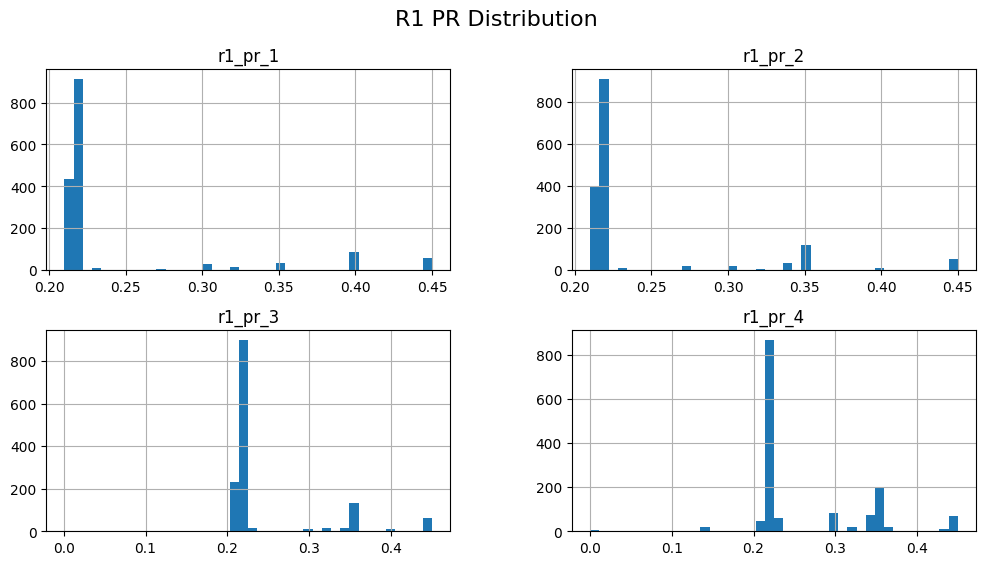

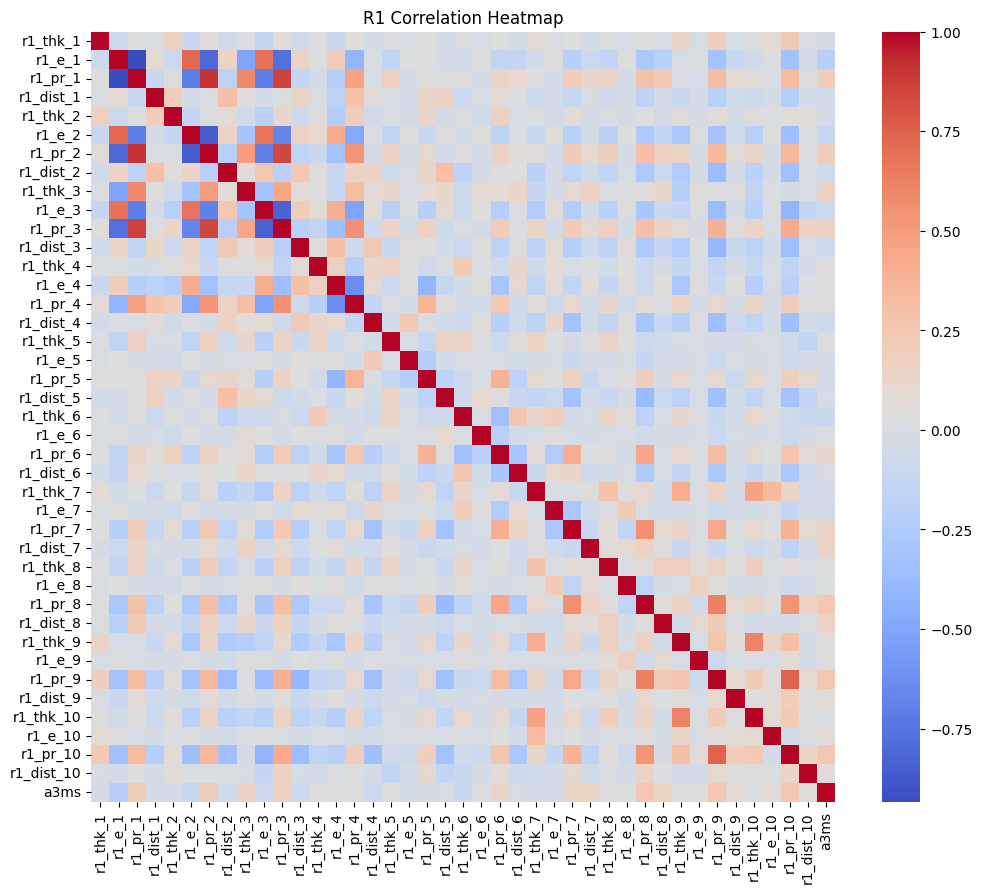

   STEP 4 — Cleaning R2 dataset

===== R2 THK — STATS =====
            count      mean        std       min           25%       50%  \
r2_thk_1   1584.0  1.496668   0.713431  0.010317  9.900000e-01  1.261847   
r2_thk_2   1584.0  1.567815   1.168998  0.000000  9.490736e-01  1.452289   
r2_thk_3   1584.0  3.207763   2.553274  0.000000  1.983394e+00  3.055456   
r2_thk_4   1584.0  3.142405   2.433713  0.000000  1.796906e+00  2.872489   
r2_thk_5   1582.0  3.019601   3.330779  0.000000  6.881985e-01  2.645635   
r2_thk_6   1578.0  3.966397   6.151224  0.000000  1.285641e+00  2.978899   
r2_thk_7   1572.0  4.788510   9.183016  0.000000  1.043750e-11  2.495218   
r2_thk_8   1559.0  3.009243   6.377314  0.000000  0.000000e+00  1.704857   
r2_thk_9   1535.0  5.237945  11.701686  0.000000  0.000000e+00  1.890000   
r2_thk_10  1497.0  4.164629  17.300390  0.000000  0.000000e+00  0.105043   

                75%         max  
r2_thk_1   1.898022    6.060930  
r2_thk_2   2.166906   10.690000  
r

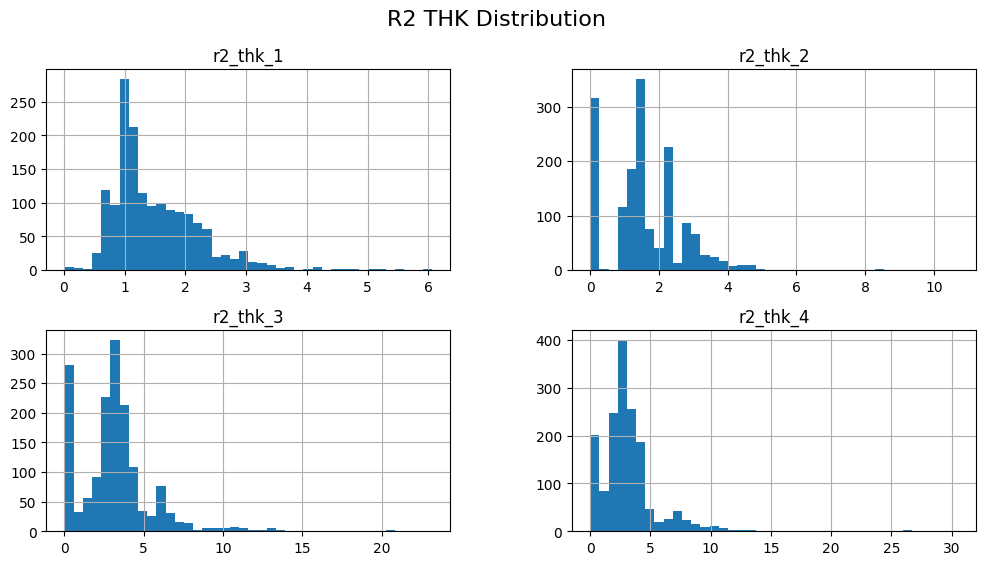


===== R2 DIST — STATS =====
             count       mean        std  min           25%       50%  \
r2_dist_1   1584.0   2.024006   5.319596  0.0  2.132500e-12  0.466102   
r2_dist_2   1584.0   9.499600  10.824468  0.0  1.230872e+00  8.771101   
r2_dist_3   1584.0  12.954740  21.413717  0.0  4.072074e-01  6.103891   
r2_dist_4   1582.0  16.031930  29.468700  0.0  1.721484e+00  6.037929   
r2_dist_5   1578.0  22.090771  42.661689  0.0  5.355000e-13  6.490075   
r2_dist_6   1572.0  20.553717  40.110326  0.0  0.000000e+00  3.126059   
r2_dist_7   1561.0  19.184148  45.595610  0.0  0.000000e+00  0.993601   
r2_dist_8   1537.0  16.620339  41.509137  0.0  0.000000e+00  0.233994   
r2_dist_9   1499.0  13.776216  36.090056  0.0  0.000000e+00  0.000000   
r2_dist_10  1472.0  11.622404  31.338568  0.0  0.000000e+00  0.000000   

                  75%         max  
r2_dist_1    0.570218   64.590000  
r2_dist_2   11.386821   86.280000  
r2_dist_3   17.422500  300.520000  
r2_dist_4   20.565090  

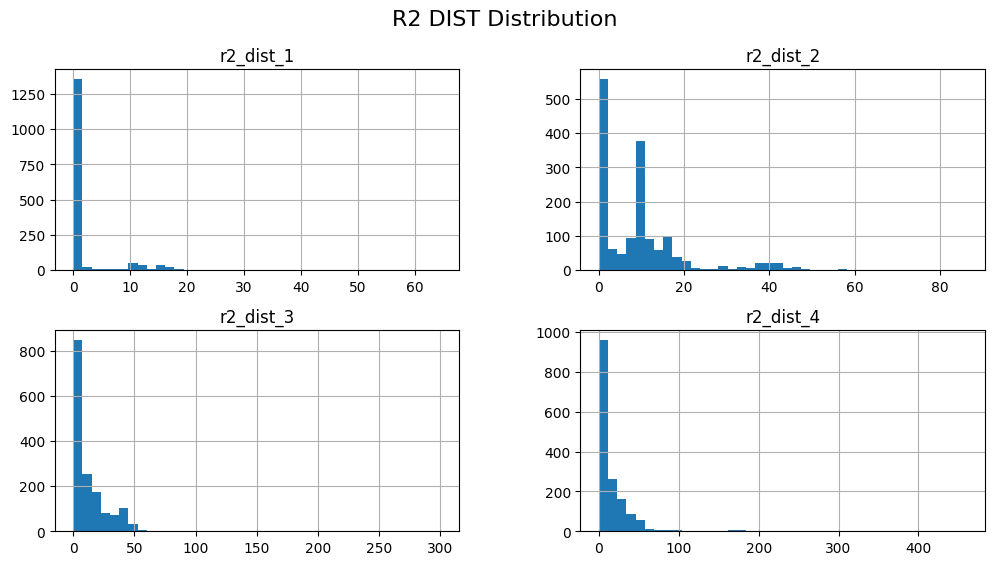


===== R2 E — STATS =====
          count        mean          std  min    25%    50%    75%      max
r2_e_1   1583.0   61.923955    21.503420  0.1  69.00  69.00  71.70     71.7
r2_e_2   1579.0   62.154807    19.533934  0.1  69.00  69.00  71.70     71.7
r2_e_3   1408.0   61.246186    21.075563  0.1  69.00  69.00  69.00    210.0
r2_e_4   1460.0   53.251158    28.909963  0.1  44.80  69.00  69.00    210.0
r2_e_5   1518.0  112.896171  2149.311709  0.0   2.40  44.80  69.00  70040.0
r2_e_6   1547.0  138.812884  2337.052872  0.0   2.35   2.95  24.00  46020.0
r2_e_7   1472.0  230.135105  3166.385910  0.0   2.20   2.55   3.35  46020.0
r2_e_8   1458.0  608.469596  5219.970381  0.0   1.15   2.45   2.95  46020.0
r2_e_9   1432.0  804.066495  6168.428723  0.0   0.10   2.40   2.95  70040.0
r2_e_10  1410.0  657.529206  5631.909301  0.0   0.10   2.35   2.95  70040.0

Missing values per column:
r2_e_1       7
r2_e_2      11
r2_e_3     182
r2_e_4     130
r2_e_5      72
r2_e_6      43
r2_e_7     118
r2_e_

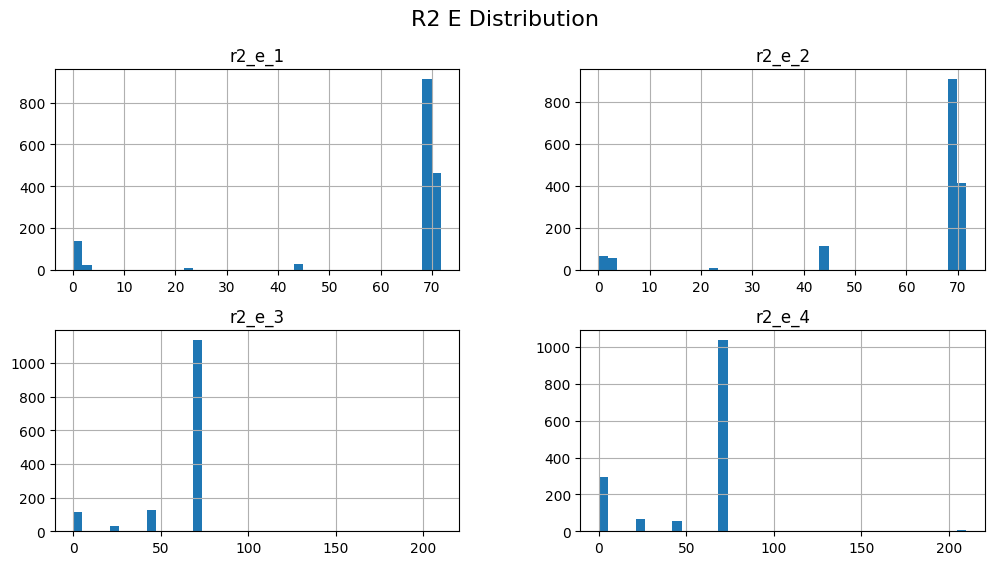


===== R2 PR — STATS =====
           count      mean       std    min    25%   50%   75%   max
r2_pr_1   1583.0  0.240513  0.061577  0.210  0.210  0.22  0.22  0.45
r2_pr_2   1579.0  0.240880  0.058227  0.070  0.210  0.22  0.22  0.45
r2_pr_3   1408.0  0.245238  0.063704  0.001  0.220  0.22  0.22  0.45
r2_pr_4   1460.0  0.257133  0.069492  0.000  0.220  0.22  0.30  0.45
r2_pr_5   1518.0  0.280051  0.088751  0.000  0.220  0.23  0.35  0.45
r2_pr_6   1547.0  0.305282  0.096287  0.000  0.220  0.34  0.35  0.45
r2_pr_7   1472.0  0.314240  0.109686  0.000  0.316  0.35  0.36  0.45
r2_pr_8   1458.0  0.298698  0.131097  0.000  0.316  0.34  0.35  0.45
r2_pr_9   1432.0  0.272084  0.149379  0.000  0.220  0.34  0.35  0.45
r2_pr_10  1410.0  0.248201  0.161824  0.000  0.070  0.34  0.35  0.45

Missing values per column:
r2_pr_1       7
r2_pr_2      11
r2_pr_3     182
r2_pr_4     130
r2_pr_5      72
r2_pr_6      43
r2_pr_7     118
r2_pr_8     132
r2_pr_9     158
r2_pr_10    180
dtype: int64

===== PHYSIC

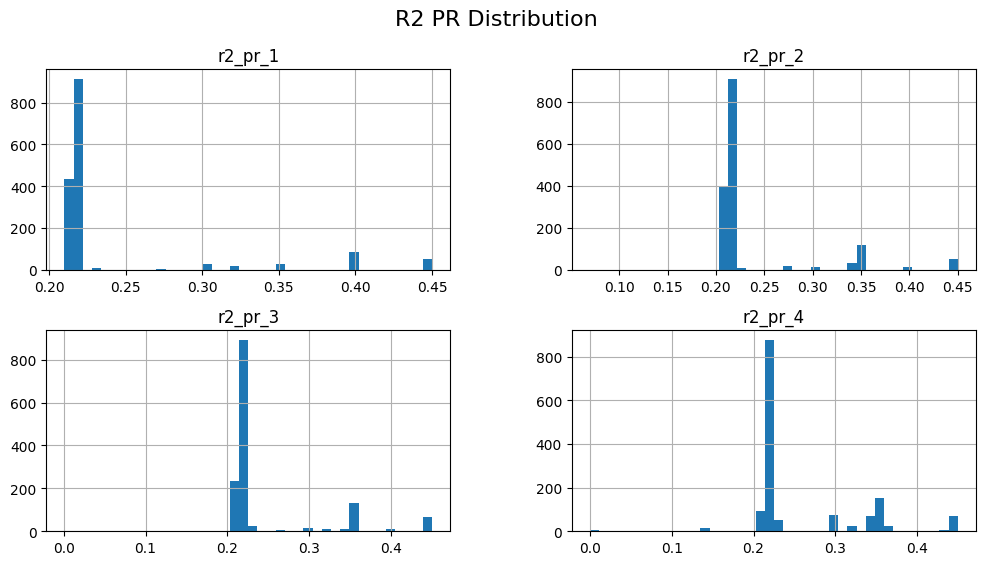

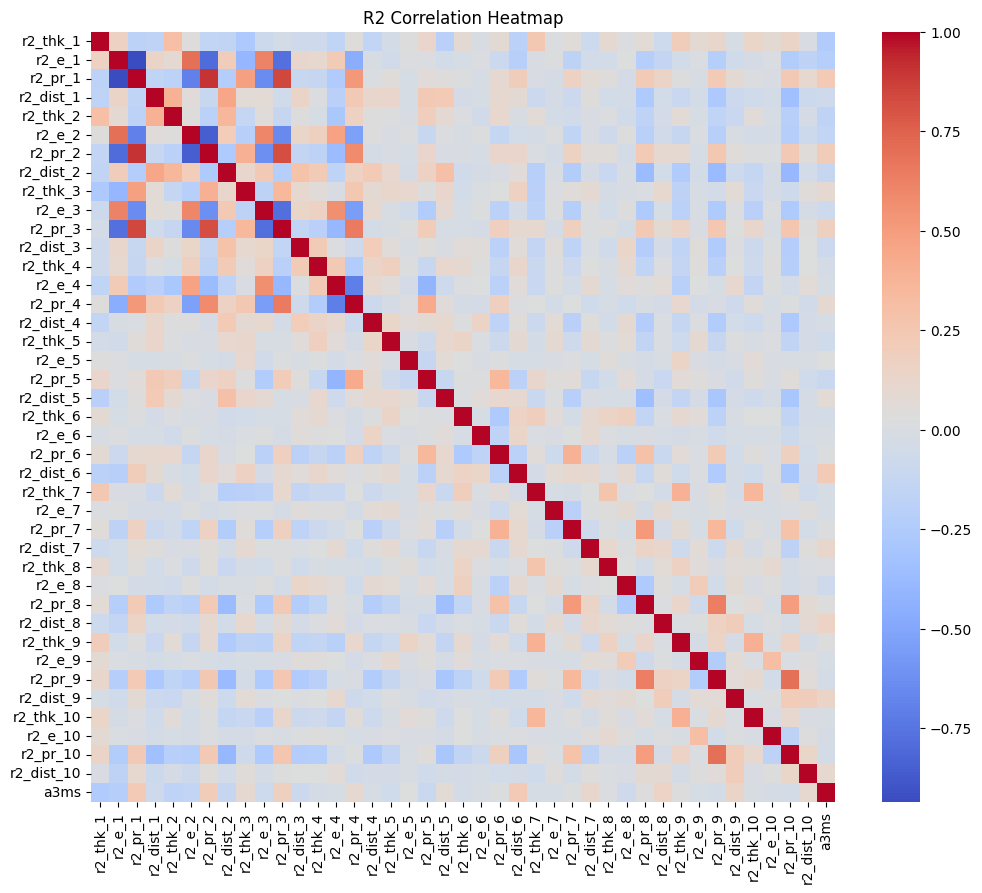

In [37]:
# Extract thk, dist, E and PR columns for a given direction (r1 or r2).
# Returns a dictionary of DataFrames.

def extract_feature_group(df, direction="r1"):
    
    groups = {
        "thk": df.filter(regex=rf"^{direction}_thk_"),
        "dist": df.filter(regex=rf"^{direction}_dist_"),
        "e": df.filter(regex=rf"^{direction}_e_"),
        "pr": df.filter(regex=rf"^{direction}_pr_")
    }
    return groups

# Convert all dataframe columns to numeric values safely.
# Invalid strings -> NaN
def safe_numeric(df):
    return df.apply(pd.to_numeric, errors="coerce")


def describe_group(group_df, group_name, direction):
    print(f"\n===== {direction.upper()} {group_name.upper()} — STATS =====")
    numeric_df = safe_numeric(group_df)
    print(numeric_df.describe().T)

    print("\nMissing values per column:")
    print(numeric_df.isna().sum())

#  Plot histograms for the first few columns of a feature group.
def plot_distribution(group_df, group_name, direction):
    print(f"\nPlotting distribution for: {direction.upper()} {group_name.upper()} ...")

    numeric_df = safe_numeric(group_df)
    cols = numeric_df.columns[: min(len(numeric_df.columns), 4)]  # plot up to 4 rays

    numeric_df[cols].hist(bins=40, figsize=(12, 6))
    plt.suptitle(f"{direction.upper()} {group_name.upper()} Distribution", fontsize=16)
    plt.show()

# Perform physics sanity checks with safe numeric conversion.
def physics_checks(group_df, group_name, direction):
    clean_df = safe_numeric(group_df)

    print(f"\n===== PHYSICS CHECKS — {direction.upper()} {group_name.upper()} =====")

    if group_name == "thk":
        invalid = (clean_df < 0).sum()
        print("Negative thickness count per column:\n", invalid)

    if group_name == "dist":
        invalid = (clean_df < 0).sum()
        print("Negative distance count per column:\n", invalid)

    if group_name == "e":
        invalid = (clean_df < 0).sum()
        print("Invalid E modulus count (<0):\n", invalid)

    if group_name == "pr":
        invalid_low = (clean_df < 0).sum()
        invalid_high = (clean_df > 0.5).sum()
        print("PR < 0 count:\n", invalid_low)
        print("PR > 0.5 count:\n", invalid_high)

# STEP 4 — APPLY CLEANING & ANALYSIS FOR R1 AND R2
for direction, df in {"r1": r1_all, "r2": r2_all}.items():
    print(f"   STEP 4 — Cleaning {direction.upper()} dataset")

    # Extract feature groups
    groups = extract_feature_group(df, direction)

    # Loop through each feature group and analyze
    for group_name, group_df in groups.items():

        # 4.1 Summary + missing values
        describe_group(group_df, group_name, direction)

        # 4.2 Physics sanity checks (with conversion fix)
        physics_checks(group_df, group_name, direction)

        # 4.3 Distribution plots (converted to numeric first)
        plot_distribution(group_df, group_name, direction)

    # 4.4 Correlation heatmap on full dataset (numeric only)
    numeric_df = safe_numeric(df)

    plt.figure(figsize=(12, 10))
    sns.heatmap(numeric_df.corr(numeric_only=True), cmap="coolwarm")
    plt.title(f"{direction.upper()} Correlation Heatmap")
    plt.show()


In [ ]:

# STEP 4 — FINAL CLEANING PIPELINE FOR R1 AND R2 DATASETS
# Produces: r1_clean, r2_clean



# SAVE RESULTS (Create directory if missing)

output_dir = "../Data/04_cleaned"
os.makedirs(output_dir, exist_ok=True)

r1_clean.to_csv(f"{output_dir}/r1_clean.csv", index=False)
r2_clean.to_csv(f"{output_dir}/r2_clean.csv", index=False)

print("\nStep 4 cleaning complete. Clean datasets saved.")


# Helper 1 — Convert all columns to numeric (safe)
def to_numeric(df):
    return df.apply(pd.to_numeric, errors="coerce")


# Helper 2 — Drop rays (columns) with too many missing values
def drop_sparse_rays(df, threshold=0.40):
    """
    Drops columns with more than 40% missing values.
    threshold = percentage of NaN allowed.
    """
    missing_frac = df.isna().mean()
    cols_to_keep = missing_frac[missing_frac < threshold].index
    return df[cols_to_keep]


# Helper 3 — Apply physics‑based cleaning rules
def physics_clean(df):
    
    clean = df.copy()

    # Thickness cannot exceed ~10 mm realistically
    thk_cols = [c for c in clean.columns if "_thk_" in c]
    clean[thk_cols] = clean[thk_cols].clip(lower=0.0, upper=10.0)

    # Distance can't be negative
    dist_cols = [c for c in clean.columns if "_dist_" in c]
    clean[dist_cols] = clean[dist_cols].clip(lower=0.0)

    # E-modulus normally <100 (based on your data)
    e_cols = [c for c in clean.columns if "_e_" in c]
    clean[e_cols] = clean[e_cols].clip(lower=0.0, upper=100.0)

    # PR must be in (0, 0.5)
    pr_cols = [c for c in clean.columns if "_pr_" in c]
    clean[pr_cols] = clean[pr_cols].clip(lower=0.0, upper=0.5)

    return clean


# Helper 4 — Drop rows missing too many values (global cleaning)
def drop_sparse_rows(df, threshold=0.30):
    """
    Drops rows where more than 30% of values are missing.
    """
    row_missing = df.isna().mean(axis=1)
    return df[row_missing < threshold]


# Helper 5 — Final function to clean an entire direction dataset
def clean_direction_dataset(df):
    
    # 1. Convert to numeric
    df = to_numeric(df)
    
    # 2. Drop rays with too many missing values
    df = drop_sparse_rays(df, threshold=0.40)

    # 3. Physics-based cleaning (clip unrealistic values)
    df = physics_clean(df)

    # 4. Drop rows with too many missing values
    df = drop_sparse_rows(df, threshold=0.30)

    # 5. Final fill remaining NaNs with median (safe)
    df = df.fillna(df.median())

    return df


# APPLY CLEANING TO R1 AND R2 DATASETS

print("Cleaning R1 dataset...")
r1_clean = clean_direction_dataset(r1_all)
print("R1 cleaned shape:", r1_clean.shape)

print("\nCleaning R2 dataset...")
r2_clean = clean_direction_dataset(r2_all)
print("R2 cleaned shape:", r2_clean.shape)

# SAVE RESULTS
r1_clean.to_csv("../Data/04_cleaned/r1_clean.csv", index=False)
r2_clean.to_csv("../Data/04_cleaned/r2_clean.csv", index=False)

print("\nStep 4 cleaning complete. Clean datasets saved.")


Step 4 cleaning complete. Clean datasets saved.
Cleaning R1 dataset...
R1 cleaned shape: (1507, 41)

Cleaning R2 dataset...
R2 cleaned shape: (1550, 41)

Step 4 cleaning complete. Clean datasets saved.


In [44]:
r2_clean.head()

,r2_thk_1,r2_e_1,r2_pr_1,r2_dist_1,r2_thk_2,r2_e_2,r2_pr_2,r2_dist_2,r2_thk_3,r2_e_3,...,r2_dist_8,r2_thk_9,r2_e_9,r2_pr_9,r2_dist_9,r2_thk_10,r2_e_10,r2_pr_10,r2_dist_10,a3ms
0,1.35,71.7,0.21,5.96,3.52,71.7,0.21,2.28,2.08,71.7,...,0.00,2.26,2.40,0.40,4.63,2.24,2.95,0.35,19.98,40.92
1,1.35,71.7,0.21,7.09,2.57,71.7,0.21,2.11,3.04,71.7,...,0.00,2.26,2.40,0.40,4.35,2.24,2.95,0.35,17.96,44.93
2,1.33,71.7,0.21,8.40,2.04,71.7,0.21,1.29,3.76,71.7,...,4.18,2.24,2.95,0.35,16.95,3.25,100.00,0.30,3.95,49.97
3,1.33,71.7,0.21,9.69,2.03,71.7,0.21,1.09,3.35,71.7,...,11.61,3.40,100.00,0.30,0.00,0.00,0.00,0.00,0.00,48.94
4,1.34,71.7,0.21,8.39,2.04,71.7,0.21,1.30,3.75,71.7,...,4.36,2.24,2.95,0.35,18.79,3.83,100.00,0.30,0.00,43.04


In [ ]:
# STEP 5 — FEATURE SELECTION + SCALING + CLASS TARGET


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import KBinsDiscretizer

# 1. SELECT FEATURES FOR ML (R1 and R2 separately)
def select_features(df, direction="r1", drop_rays=None):

    # Select ray-based features (thk, dist, e, pr) + target.
    # drop_rays: list of ray indices to remove (e.g., [8, 9, 10])

    feature_cols = []

    for col in df.columns:
        if col.startswith(direction + "_"):
            # If specific rays must be dropped
            if drop_rays is not None:
                valid = True
                for r in drop_rays:
                    if col.startswith(f"{direction}_thk_{r}") or \
                       col.startswith(f"{direction}_dist_{r}") or \
                       col.startswith(f"{direction}_e_{r}") or \
                       col.startswith(f"{direction}_pr_{r}"):
                        valid = False
                        break
                if not valid:
                    continue
            feature_cols.append(col)

    # Target column (your output variable)
    target_col = "a3ms"

    X = df[feature_cols].copy()
    y = df[target_col].copy()

    return X, y


# 2. APPLY FEATURE SELECTION
# R1 → drop rays 8, 9, 10 (they are mostly zeros)
drop_r1 = [8, 9, 10]
X_r1, y_r1 = select_features(r1_clean, direction="r1", drop_rays=drop_r1)

# R2 → KEEP all rays (they have meaningful values)
drop_r2 = None
X_r2, y_r2 = select_features(r2_clean, direction="r2", drop_rays=drop_r2)

print("R1 features:", X_r1.shape)
print("R2 features:", X_r2.shape)


# 3. TRAIN-TEST SPLIT (DO THIS BEFORE SCALING!)
X_r1_train, X_r1_test, y_r1_train, y_r1_test = train_test_split(
    X_r1, y_r1, test_size=0.2, random_state=42
)

X_r2_train, X_r2_test, y_r2_train, y_r2_test = train_test_split(
    X_r2, y_r2, test_size=0.2, random_state=42
)

print("R1 train:", X_r1_train.shape, "R2 train:", X_r2_train.shape)



# 4. SCALE FEATURES (ZERO MEAN, UNIT VARIANCE)
# IMPORTANT: Fit ONLY on training data → Avoid leakage

scaler_r1 = StandardScaler()
X_r1_train_scaled = scaler_r1.fit_transform(X_r1_train)
X_r1_test_scaled  = scaler_r1.transform(X_r1_test)

scaler_r2 = StandardScaler()
X_r2_train_scaled = scaler_r2.fit_transform(X_r2_train)
X_r2_test_scaled  = scaler_r2.transform(X_r2_test)

print("Scaling completed.")



# 5. OPTIONAL — CONVERT CONTINUOUS TARGET (y) TO CLASSES
# Useful if you want classification instead of regression.

# Convert continuous y → class labels using binning. #Quantile binning gives balanced classes.
def convert_target_to_classes(y, n_bins=3, strategy="quantile"):

    kb = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy=strategy)
    classes = kb.fit_transform(y.values.reshape(-1,1)).astype(int)
    return classes, kb

# Example: 3 classes (low, medium, high stiffness)
y_r1_class, bin_r1 = convert_target_to_classes(y_r1_train)
y_r2_class, bin_r2 = convert_target_to_classes(y_r2_train)

print("Class conversion completed.")

R1 features: (1507, 28)
R2 features: (1550, 40)
R1 train: (1205, 28) R2 train: (1240, 40)
Scaling completed.
Class conversion completed.


C:\Users\skatrev\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\skatrev\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [ ]:
# STEP 6A — REGRESSION MODEL PERFORMANCE COMPARISON
models_reg = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR_RBF": SVR(kernel="rbf", C=10, epsilon=0.1),
    "NeuralNet": MLPRegressor(hidden_layer_sizes=(64, 32),
                              activation="relu",
                              max_iter=600,
                              random_state=42)
}

def evaluate_regression(models, X_train, y_train, X_test, y_test):
    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        results[name] = {
            "RMSE": mean_squared_error(y_test, pred) ** 0.5,
            "MAE": mean_absolute_error(y_test, pred),
            "R2": r2_score(y_test, pred)
        }
    return pd.DataFrame(results).T


# Run regression comparison for R1
print("\n========== R1 Regression Performance ==========")
r1_reg_results = evaluate_regression(
    models_reg,
    X_r1_train_scaled, y_r1_train,
    X_r1_test_scaled, y_r1_test
)
print(r1_reg_results)

# Run regression comparison for R2
print("\n========== R2 Regression Performance ==========")
r2_reg_results = evaluate_regression(
    models_reg,
    X_r2_train_scaled, y_r2_train,
    X_r2_test_scaled, y_r2_test
)
print(r2_reg_results)

# EXTRA: PRINT BEST MODELS (based on lowest RMSE)
def print_best_model(results_df, label):
    best_model = results_df.sort_values("RMSE").iloc[0]
    best_name = results_df.sort_values("RMSE").index[0]

    print(f"\n===== BEST {label} REGRESSION MODEL =====")
    print(f"Model: {best_name}")
    print(best_model)


# Best model for R1
print_best_model(r1_reg_results, "R1")

# Best model for R2
print_best_model(r2_reg_results, "R2")


========== R1 Regression Performance ==========
                      RMSE       MAE        R2
LinearRegression  9.917367  7.982051  0.054991
RandomForest      6.818021  5.077942  0.553358
GradientBoosting  6.996198  5.357262  0.529708
SVR_RBF           8.506584  6.501305  0.304730
NeuralNet         8.777933  6.573130  0.259666

========== R2 Regression Performance ==========
                       RMSE       MAE        R2
LinearRegression   9.908820  7.897351  0.154712
RandomForest       7.544843  5.415044  0.509926
GradientBoosting   7.545824  5.697653  0.509799
SVR_RBF            8.293455  6.342174  0.407849
NeuralNet         10.097138  7.072748  0.122277

===== BEST R1 REGRESSION MODEL =====
Model: RandomForest
RMSE    6.818021
MAE     5.077942
R2      0.553358
Name: RandomForest, dtype: float64

===== BEST R2 REGRESSION MODEL =====
Model: RandomForest
RMSE    7.544843
MAE     5.415044
R2      0.509926
Name: RandomForest, dtype: float64


C:\Users\skatrev\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


In [4]:
# ================================================================
# STEP 6B — CLASSIFICATION MODEL PERFORMANCE COMPARISON
# ================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# ------------------------------------------
# CLASSIFICATION MODELS
# ------------------------------------------
models_clf = {
    "LogisticRegression": LogisticRegression(max_iter=300),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "SVC_RBF": SVC(kernel='rbf', C=10),
    "NeuralNet": MLPClassifier(hidden_layer_sizes=(64, 32),
                               activation="relu",
                               max_iter=600,
                               random_state=42)
}


# ------------------------------------------
# EVALUATION FUNCTION
# ------------------------------------------
def evaluate_classification(models, X_train, y_train, X_test, y_test):
    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        results[name] = {
            "Accuracy": accuracy_score(y_test, pred),
            "F1_score": f1_score(y_test, pred, average='weighted')
        }

    return pd.DataFrame(results).T


# ------------------------------------------
# RUN FOR R1 CLASSIFICATION
# ------------------------------------------
print("\n========== R1 Classification Performance ==========")
r1_cls_results = evaluate_classification(
    models_clf,
    X_r1_train_scaled, y_r1_class.ravel(),
    X_r1_test_scaled, y_r1_class.ravel()
)
print(r1_cls_results)


# ------------------------------------------
# RUN FOR R2 CLASSIFICATION
# ------------------------------------------
print("\n========== R2 Classification Performance ==========")
r2_cls_results = evaluate_classification(
    models_clf,
    X_r2_train_scaled, y_r2_class.ravel(),
    X_r2_test_scaled, y_r2_class.ravel()
)
print(r2_cls_results)


# ================================================================
# PRINT BEST MODEL (based on highest F1-score)
# ================================================================
def print_best_classifier(results_df, label):
    best_model_name = results_df.sort_values("F1_score", ascending=False).index[0]
    best_row = results_df.loc[best_model_name]

    print(f"\n===== BEST {label} CLASSIFICATION MODEL =====")
    print(f"Model: {best_model_name}")
    print(best_row)


# Best model for R1
print_best_classifier(r1_cls_results, "R1")

# Best model for R2
print_best_classifier(r2_cls_results, "R2")



========== R1 Classification Performance ==========


NameError: name 'X_r1_train_scaled' is not defined